# MECH 309: Assignment 6, Question 4

_Cagri Arslan_

April 15, 2026

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import brusselator
importlib.reload(brusselator)

from brusselator import run_brusselator_2d

# a) First-order vector-valued initial value problem

Let the unknown vector be

$$
\mathbf{y}(t) =
\begin{bmatrix}
u(t) \\
v(t)
\end{bmatrix}.
$$

Then the spatially homogeneous Brusselator system can be written as

$$
\dot{\mathbf{y}}(t) = \mathbf{f}(t,\mathbf{y}(t)), \qquad \mathbf{y}(0) = \mathbf{y}_0,
$$

with

$$
\mathbf{f}(t,\mathbf{y}) =
\begin{bmatrix}
A - (B+1)y_1 + y_1^2 y_2 \\
B y_1 - y_1^2 y_2
\end{bmatrix}.
$$

The system is autonomous, so $\mathbf{f}$ does not explicitly depend on $t$.

For the two parameter cases requested in the problem:

- when $A = 1$ and $B = 1.5$, the initial condition is
  $$
  \mathbf{y}_0 =
  \begin{bmatrix}
  1.2 \\
  1.4
  \end{bmatrix},
  $$
- when $A = 1$ and $B = 3$, the initial condition is
  $$
  \mathbf{y}_0 =
  \begin{bmatrix}
  1.2 \\
  2.9
  \end{bmatrix}.
  $$

# b) Numerical integration of the 0D Brusselator

To integrate the ODE system on $0 \leq t \leq 100$ with time step $\Delta t = 10^{-2}$, I use the classical fourth-order Runge-Kutta method. This satisfies the requirement of using a self-implemented method of at least second-order accuracy.

In [2]:
def rhs_ode(y, A, B):
    """
    Right-hand side of the spatially homogeneous Brusselator ODE.
    """
    # Unpack the current state.
    u, v = y

    # Compute the two ODE components.
    du_dt = A - (B + 1.0) * u + u**2 * v
    dv_dt = B * u - u**2 * v

    return np.array([du_dt, dv_dt], dtype=float)


def rk4_step_ode(y, dt, A, B):
    """
    One classical RK4 step for the ODE system.
    """
    # Stage 1
    k1 = rhs_ode(y, A, B)

    # Stage 2
    k2 = rhs_ode(y + 0.5 * dt * k1, A, B)

    # Stage 3
    k3 = rhs_ode(y + 0.5 * dt * k2, A, B)

    # Stage 4
    k4 = rhs_ode(y + dt * k3, A, B)

    # RK4 update
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def solve_ode(A, B, u0, v0, dt=1e-2, T=100.0):
    """
    Solve the 0D Brusselator using RK4.
    """
    # Number of time steps and corresponding time array.
    n_steps = int(T / dt)
    t = np.linspace(0.0, T, n_steps + 1)

    # Allocate storage for the solution.
    y = np.zeros((n_steps + 1, 2), dtype=float)
    y[0] = [u0, v0]

    # March forward in time.
    for n in range(n_steps):
        y[n + 1] = rk4_step_ode(y[n], dt, A, B)

    return t, y[:, 0], y[:, 1]

### i) Case $A = 1$, $B = 1.5$

In [3]:
# Solve the first ODE case.
t1, u1, v1 = solve_ode(A=1.0, B=1.5, u0=1.2, v0=1.4, dt=1e-2, T=100.0)

# Plot u(t) and v(t) for the first case.
plt.figure(figsize=(9, 4.5))
plt.plot(t1, u1, label="$u(t)$")
plt.plot(t1, v1, label="$v(t)$")
plt.title("0D Brusselator for $A=1$, $B=1.5$")
plt.xlabel("$t$")
plt.ylabel("Solution value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

For $B = 1.5$, both solution components approach constant values after an initial transient. The approach is oscillatory, but the oscillations decay with time. This indicates that the homogeneous steady state is stable in this parameter regime.

### ii) Case $A = 1$, $B = 3$

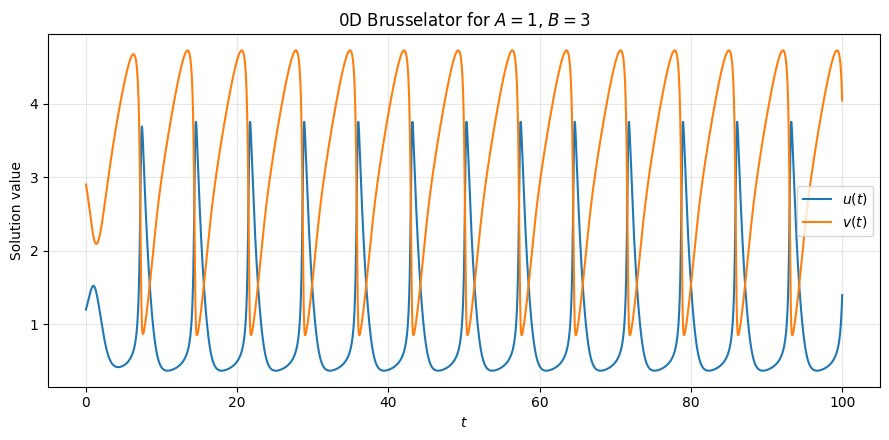

In [ ]:
# Solve the second ODE case.
t2, u2, v2 = solve_ode(A=1.0, B=3.0, u0=1.2, v0=2.9, dt=1e-2, T=100.0)

# Plot u(t) and v(t) for the second case.
plt.figure(figsize=(9, 4.5))
plt.plot(t2, u2, label="$u(t)$")
plt.plot(t2, v2, label="$v(t)$")
plt.title("0D Brusselator for $A=1$, $B=3$")
plt.xlabel("$t$")
plt.ylabel("Solution value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

For $B = 3$, the solution does not settle to a constant steady state. Instead, after the initial transient, both $u(t)$ and $v(t)$ continue to oscillate with sustained amplitude. This indicates persistent time-periodic behavior.

# c) Comment on the observed temporal behavior

The homogeneous steady state of the Brusselator is obtained by setting the right-hand sides to zero, which gives

$$
u^* = A, \qquad v^* = \frac{B}{A}.
$$

For the present ODE runs, $A = 1$, so the steady state is $(u^*, v^*) = (1, B)$.

The numerical results show two qualitatively different behaviors:

- for $B = 1.5$, the solution approaches the steady state with damped oscillations,
- for $B = 3$, the solution exhibits sustained oscillations instead of converging.

Thus, increasing $B$ changes the long-time dynamics from convergence to periodic behavior.

# d) Discretization of the Laplacian and boundary conditions

On a uniform two-dimensional grid, the Laplacian is approximated using second-order central finite differences. For the variable $u$, this gives

$$
(\nabla^2 u)_{i,j}
\approx
\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}
+
\frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta y^2}.
$$

Similarly, for $v$,

$$
(\nabla^2 v)_{i,j}
\approx
\frac{v_{i+1,j} - 2v_{i,j} + v_{i-1,j}}{\Delta x^2}
+
\frac{v_{i,j+1} - 2v_{i,j} + v_{i,j-1}}{\Delta y^2}.
$$

The problem specifies periodic boundary conditions. Therefore, values wrap around the domain:

$$
u_{-1,j} = u_{N_x-1,j}, \qquad u_{N_x,j} = u_{0,j},
$$

$$
u_{i,-1} = u_{i,N_y-1}, \qquad u_{i,N_y} = u_{i,0},
$$

and the same relations hold for $v$.

# e) Semi-discrete ODE system

Using the finite-difference approximation from part d), the reaction-diffusion PDE becomes a coupled system of ODEs for the grid values $u_{i,j}(t)$ and $v_{i,j}(t)$:

$$
\frac{d u_{i,j}}{dt}
=
A - (B+1)u_{i,j} + u_{i,j}^2 v_{i,j}
+
D_u
\left(
\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta x^2}
+
\frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta y^2}
\right),
$$

$$
\frac{d v_{i,j}}{dt}
=
B u_{i,j} - u_{i,j}^2 v_{i,j}
+
D_v
\left(
\frac{v_{i+1,j} - 2v_{i,j} + v_{i-1,j}}{\Delta x^2}
+
\frac{v_{i,j+1} - 2v_{i,j} + v_{i,j-1}}{\Delta y^2}
\right).
$$

This semi-discrete system is integrated in time using a self-coded fourth-order Runge-Kutta method implemented in `brusselator.py`.

# f) 2D numerical solution with a self-coded Runge-Kutta method

I now solve the reaction-diffusion Brusselator on the square domain $[0,5] \times [0,5]$ using the parameter values

$$
A = 2.5, \qquad B = 10.0, \qquad D_u = 0.004, \qquad D_v = 0.002.
$$

The initial condition is a small random perturbation of the homogeneous steady state,

$$
u(x,y,0) = A + 0.005\,\eta_1(x,y), \qquad
v(x,y,0) = \frac{B}{A} + 0.005\,\eta_2(x,y),
$$

where $\eta_1$ and $\eta_2$ are random values in $[-1,1]$.

### i) Run with $N_x = N_y = 100$

In [ ]:
# Choose the times at which snapshots will be displayed.
snapshot_times = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0]

# Run the 2D Brusselator on a 100 x 100 grid.
x100, y100, u100_snaps, v100_snaps, u100_final, v100_final = run_brusselator_2d(
    Nx=100,
    Ny=100,
    snapshot_times=snapshot_times
)

KeyboardInterrupt: 

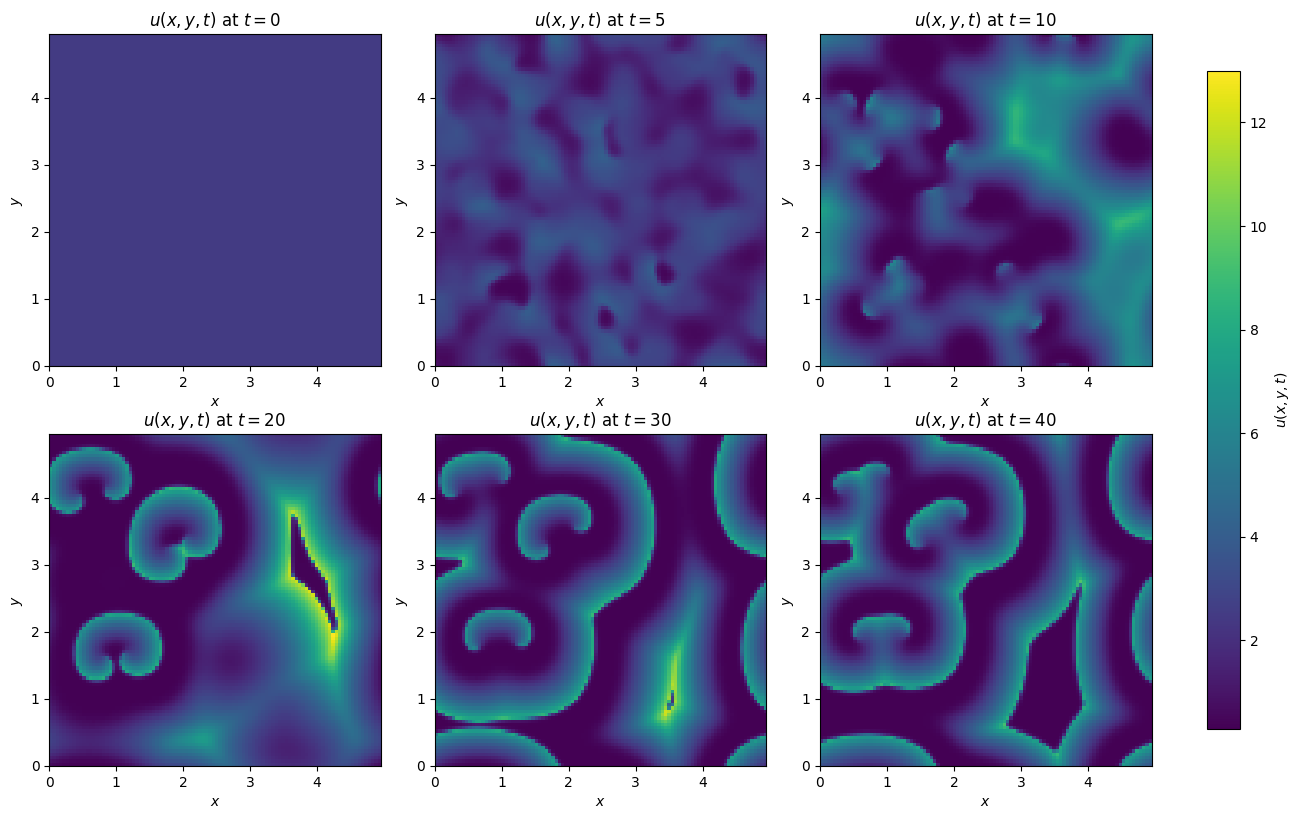

In [ ]:
# Plot selected snapshots of u(x,y,t) for the 100 x 100 case.
# Use one common color scale so the panels are visually comparable.
u100_fields = [u100_snaps[t] for t in snapshot_times]
vmin_100 = min(field.min() for field in u100_fields)
vmax_100 = max(field.max() for field in u100_fields)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for ax, t in zip(axes, snapshot_times):
    # Plot with a shared color scale across all times.
    im = ax.imshow(
        u100_snaps[t].T,
        origin="lower",
        extent=[x100[0], x100[-1], y100[0], y100[-1]],
        aspect="equal",
        vmin=vmin_100,
        vmax=vmax_100
    )
    ax.set_title(f"$u(x,y,t)$ at $t={t:g}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

# Add a single shared colorbar.
fig.colorbar(im, ax=axes, shrink=0.9, label="$u(x,y,t)$")

plt.show()

For the $100 \times 100$ grid, the solution begins very close to the spatially homogeneous steady state. Since the initial perturbation has amplitude only $0.005$, the field at $t=0$ is nearly uniform. As time increases, the perturbations are amplified and organize into visible spatial structure. By later times, the solution clearly exhibits a nonuniform reaction-diffusion pattern rather than remaining spatially homogeneous.

# g) Visualization and discussion of the dynamics

The numerical solution shows pattern formation from a nearly homogeneous initial state. At early times, the field is only weakly perturbed. As time increases, the perturbations grow and organize into visible structures. This is consistent with diffusion-driven instability in the Brusselator model.

Because periodic boundary conditions are used, patterns crossing one side of the domain reappear on the opposite side, so the structure wraps around continuously.

### ii) Repeat with $N_x = N_y = 200$ and $N_x = N_y = 400$

In [ ]:
# Run the same simulation on finer grids.
x200, y200, u200_snaps, v200_snaps, u200_final, v200_final = run_brusselator_2d(
    Nx=200,
    Ny=200,
    snapshot_times=snapshot_times
)

In [ ]:
x400, y400, u400_snaps, v400_snaps, u400_final, v400_final = run_brusselator_2d(
    Nx=400,
    Ny=400,
    snapshot_times=snapshot_times
)

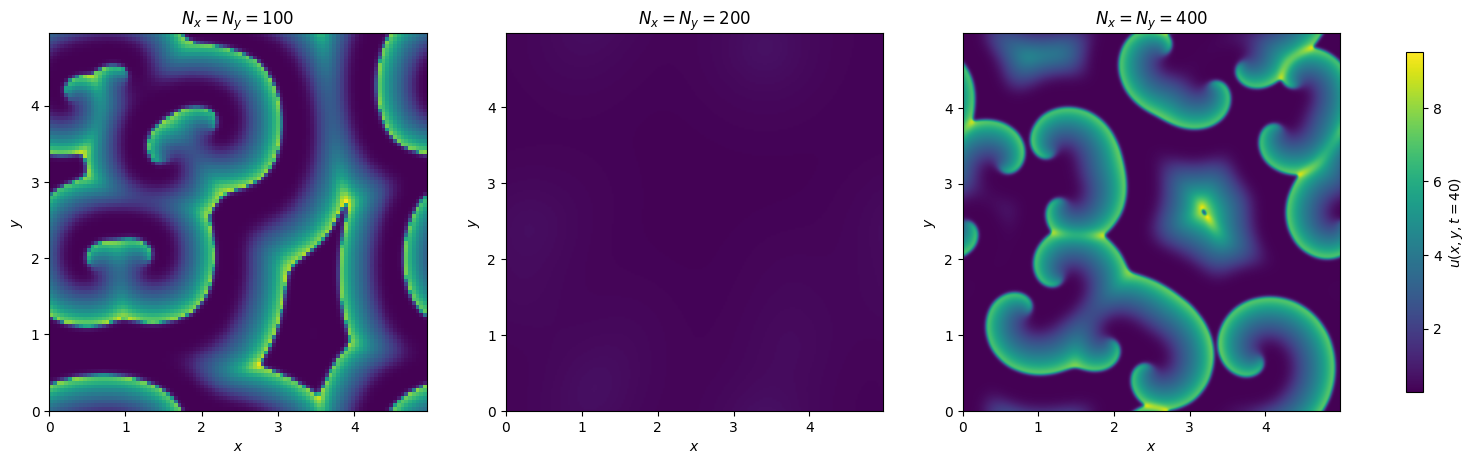

In [ ]:
# Compare the final-time solution across the three grid resolutions.
# Use one common color scale across all three plots.
final_fields = [u100_snaps[40.0], u200_snaps[40.0], u400_snaps[40.0]]
vmin_final = min(field.min() for field in final_fields)
vmax_final = max(field.max() for field in final_fields)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].imshow(
    u100_snaps[40.0].T,
    origin="lower",
    extent=[x100[0], x100[-1], y100[0], y100[-1]],
    aspect="equal",
    vmin=vmin_final,
    vmax=vmax_final
)
axes[0].set_title("$N_x = N_y = 100$")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")

im1 = axes[1].imshow(
    u200_snaps[40.0].T,
    origin="lower",
    extent=[x200[0], x200[-1], y200[0], y200[-1]],
    aspect="equal",
    vmin=vmin_final,
    vmax=vmax_final
)
axes[1].set_title("$N_x = N_y = 200$")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")

im2 = axes[2].imshow(
    u400_snaps[40.0].T,
    origin="lower",
    extent=[x400[0], x400[-1], y400[0], y400[-1]],
    aspect="equal",
    vmin=vmin_final,
    vmax=vmax_final
)
axes[2].set_title("$N_x = N_y = 400$")
axes[2].set_xlabel("$x$")
axes[2].set_ylabel("$y$")

# Add a shared colorbar.
fig.colorbar(im2, ax=axes, shrink=0.9, label="$u(x,y,t=40)$")

plt.show()

All three grid resolutions develop nonuniform spatial structure, confirming the same qualitative pattern-forming behavior. However, the exact pattern is not identical across the three runs, since the initial perturbation is random and depends on the grid resolution.

The main effect of refining the grid is therefore not that the same pattern is reproduced point-for-point, but that thinner interfaces and smaller-scale spatial features can be resolved more clearly. Thus, the finer grids provide better spatial resolution, while preserving the same overall reaction-diffusion dynamics.

# Final remarks

The 0D Brusselator shows two distinct temporal regimes depending on the parameter $B$: convergence to a steady state for $B = 1.5$, and sustained oscillations for $B = 3$.

The 2D reaction-diffusion Brusselator shows spatial pattern formation when small perturbations are introduced near the homogeneous steady state. The finite-difference discretization with periodic boundary conditions and a self-coded RK4 time integrator successfully captures the onset and development of these patterns.